Comparative analysis of results in Bologna:

Land Surface Temperature predicted from High resolution data and open Global datasets

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
lst_observed = 
lst_predicted_hr_data = '../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/LST_predicted_RF.tif'
lst_predicted_global_data = '../../datos-notebooks/2.global-data-bologna/LST-prediction/LST_predicted_RF.tif'
out_diff = '../../datos-notebooks/4.comparative-analysis/LST_difference_bologna.tif'

In [3]:
os.makedirs(os.path.dirname(out_diff), exist_ok=True)

with rasterio.open(lst_predicted_hr_data) as src1, rasterio.open(lst_predicted_global_data) as src2:

    # Read bands as float 
    r1 = src1.read(1).astype("float32")
    r2 = src2.read(1).astype("float32")

    # Difference 
    diff = r1 - r2

    # Save output raster 
    profile = src1.profile
    profile.update(dtype="float32")

    with rasterio.open(out_diff, "w", **profile) as dst:
        dst.write(diff.astype("float32"), 1)
        
    print("Saved in:", out_diff)

Saved in: ../../datos-notebooks/comparative-analysis/LST_difference_bologna.tif


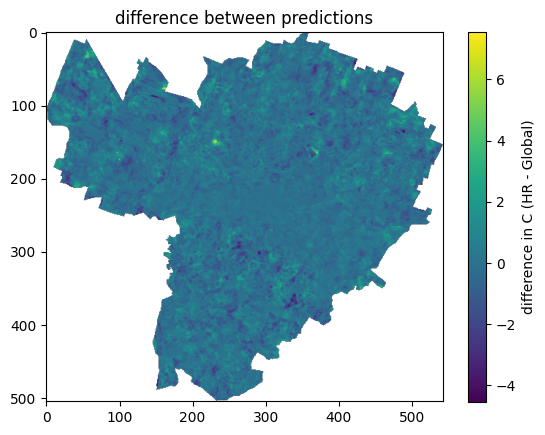

In [4]:
# Plot result -- comments in english
with rasterio.open(lst_predicted_hr_data) as src:
    xmin, ymin, xmax, ymax = src.bounds

plt.figure()
plt.title("difference between predictions")
plt.imshow(diff, cmap='viridis')
plt.colorbar(label="difference in C (HR - Global)")
plt.show()


In [5]:
# Quantify raster differences
import numpy as np

with rasterio.open(out_diff) as srcd:
    diff = srcd.read(1).astype("float32")
    nodata = srcd.nodata

# Build valid mask
mask = np.isfinite(diff)
if nodata is not None:
    mask &= (diff != nodata)

d = diff[mask]

# Basic stats 
print(f"Mean diff: {np.mean(d):.3f}")
print(f"Median diff: {np.median(d):.3f}")
print(f"Std diff: {np.std(d):.3f}")

# Error-like metrics 
mae = float(np.mean(np.abs(d)))
rmse = float(np.sqrt(np.mean(d**2)))
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


Mean diff: 0.003
Median diff: -0.007
Std diff: 0.695
MAE: 0.491
RMSE: 0.695


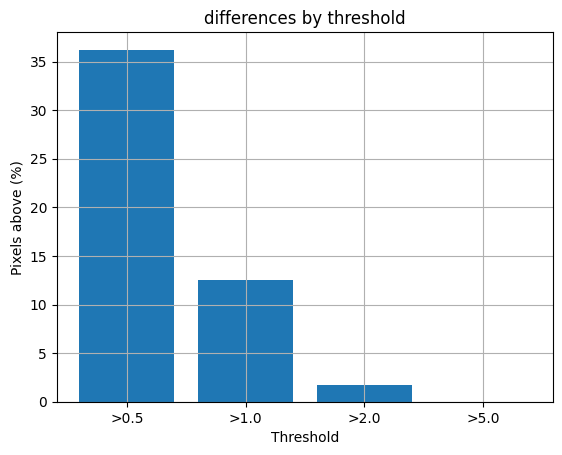

In [24]:
# Plot bar chart with threshold labels
thresholds = [0.5, 1.0, 2.0, 5.0]
fractions = [float(np.mean(np.abs(d) > thr)) * 100 for thr in thresholds]

plt.figure()
plt.title("differences by threshold")

bars = plt.bar(range(len(thresholds)), fractions) # Create bars

plt.xlabel("Threshold")
plt.ylabel("Pixels above (%)")
plt.grid(True)
plt.xticks(range(len(thresholds)), [f">{t}" for t in thresholds])
plt.show()
